In [1]:
import os
import glob
import random
from pathlib import Path
import numpy as np
from scipy.stats import kruskal
import pandas as pd
import h5py
import anndata
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
import seaborn as sns
from PIL import Image
import openslide
from skimage.measure import regionprops_table
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors  # 注意导入这个
import pandas as pd
from PIL import Image, ImageDraw

import scanpy as sc
import anndata
import leidenalg

import sys
sys.path.append('/scratch/users/k21066795/NBT-phenotyping')
from utils_pheno import * 

import warnings
warnings.filterwarnings("ignore")

In [2]:
basedir = '/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS'
save_prefix = f"{basedir}/WSI_mapping05"
print(save_prefix)
print(os.listdir(f"{basedir}/NBTs_phenotypes03"))

/scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/WSI_mapping05
['umap', 'UNI_MHSA', 'nuclei_quantification', 'heatmap', 'NBT-Classifier_annotation', 'patches_examples', 'Clustree', 'adata']


In [3]:
file_path = f"{basedir}/NBTs_phenotypes03/adata/adata_NBTs_4levels.h5ad"
adata_normal = sc.read_h5ad(file_path)
adata_normal.obs

,patient_id,age,patch_id,cohort,wsi_id,source,leiden_0.5,umap1,umap2,leiden_0.5_top_samples,leiden_1.0,leiden_1.5,leiden_2.0,risk
0,1003675,NaN,BRACS_1003675_N_1_1792_768,BRCAS,BRACS_1003675_N_1,N,1,3.759436,8.816525,False,0,1,1,2
1,1003675,NaN,BRACS_1003675_N_1_256_1024,BRCAS,BRACS_1003675_N_1,N,5,0.320499,4.078640,False,11,21,31,2
2,1003675,NaN,BRACS_1003675_N_1_1280_768,BRCAS,BRACS_1003675_N_1,N,1,4.204348,8.063508,False,0,1,1,2
3,1003675,NaN,BRACS_1003675_N_1_768_1024,BRCAS,BRACS_1003675_N_1,N,4,0.990095,4.295871,False,11,17,25,2
4,1003675,NaN,BRACS_1003675_N_1_256_1280,BRCAS,BRACS_1003675_N_1,N,5,0.473569,4.100793,False,11,21,31,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97271,773,NaN,BRACS_773_N_33_768_0,BRCAS,BRACS_773_N_33,N,1,3.437264,9.901889,False,0,14,28,2
97272,773,NaN,BRACS_773_N_33_768_256,BRCAS,BRACS_773_N_33,N,3,5.882754,1.325934,False,2,5,18,2
97273,773,NaN,BRACS_773_N_33_1280_512,BRCAS,BRACS_773_N_33,N,5,2.701497,2.551752,False,4,4,24,2
97274,773,NaN,BRACS_773_N_33_2048_512,BRCAS,BRACS_773_N_33,N,1,3.388751,4.773305,False,1,4,24,2


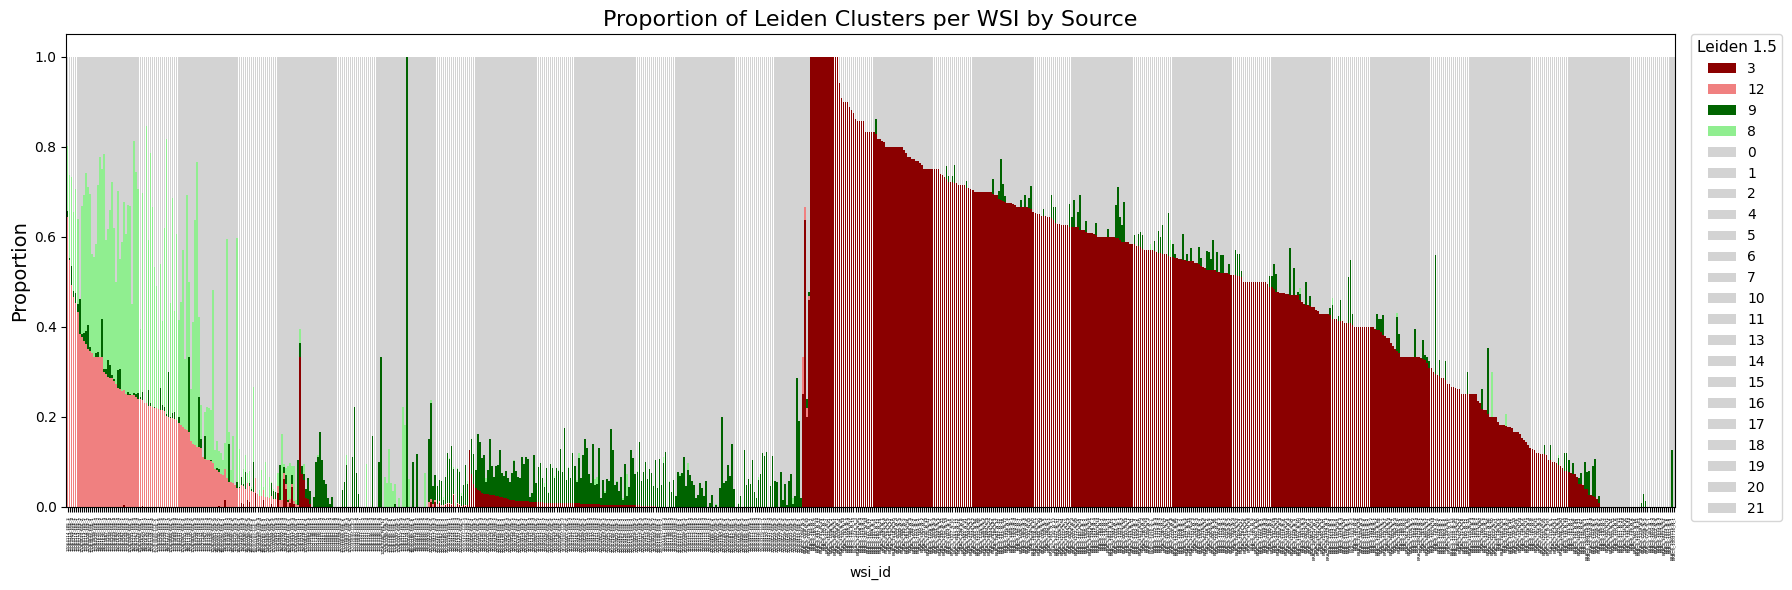

In [16]:
# Absolute abundance of Clusters 3, 8, 9, 12
subset = adata_normal.obs.copy()
clusters = ['3', '12', '9', '8']
wsi_source = subset[['wsi_id', 'source']].drop_duplicates().set_index('wsi_id')
counts = subset.groupby(['wsi_id', 'leiden_1.5']).size().unstack(fill_value=0)
proportions = counts.div(counts.sum(axis=1), axis=0)
proportions = proportions.merge(wsi_source, left_index=True, right_index=True)
source_order = ['N_RM', 'N_RRM', 'N']
proportions['source'] = pd.Categorical(proportions['source'], categories=source_order, ordered=True)
proportions = proportions.sort_values(by=['source', '12', '3'], ascending=[True, False, False])
all_clusters = [col for col in proportions.columns if col != 'source']
plot_cols = clusters + [col for col in all_clusters if col not in clusters]


colors = {
    '3': '#8B0000',    # dark red
    '12': '#F08080',   # light red
    '9': '#006400',    # dark green
    '8': '#90EE90'     # light green
}
lightgrey = 'lightgrey'
color_map = [colors.get(c, lightgrey) for c in plot_cols]
plot_data = proportions[plot_cols]


fig, ax = plt.subplots(figsize=(18, 6))
plot_data.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=color_map,
    width=0.8
)
ax.set_ylabel("Proportion", fontsize=14)
ax.set_title("Proportion of Leiden Clusters per WSI by Source", fontsize=16)
ax.set_xticklabels(plot_data.index, rotation=90, fontsize=8)
for tick, wsi_id in enumerate(plot_data.index):
    source_label = proportions.loc[wsi_id, 'source']
    ax.annotate(source_label, (tick, -0.05), xycoords='data',
                ha='center', va='top', fontsize=8, rotation=90)
ax.legend(
    title="Leiden 1.5", 
    fontsize=10, 
    title_fontsize=11,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0.
)
ax.set_xticklabels(plot_data.index, rotation=90, fontsize=3)


plt.tight_layout()
save_pt = f"{save_prefix}/leiden_1.5_clusters_3_8_9_12_stacked_barplot_absolute.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

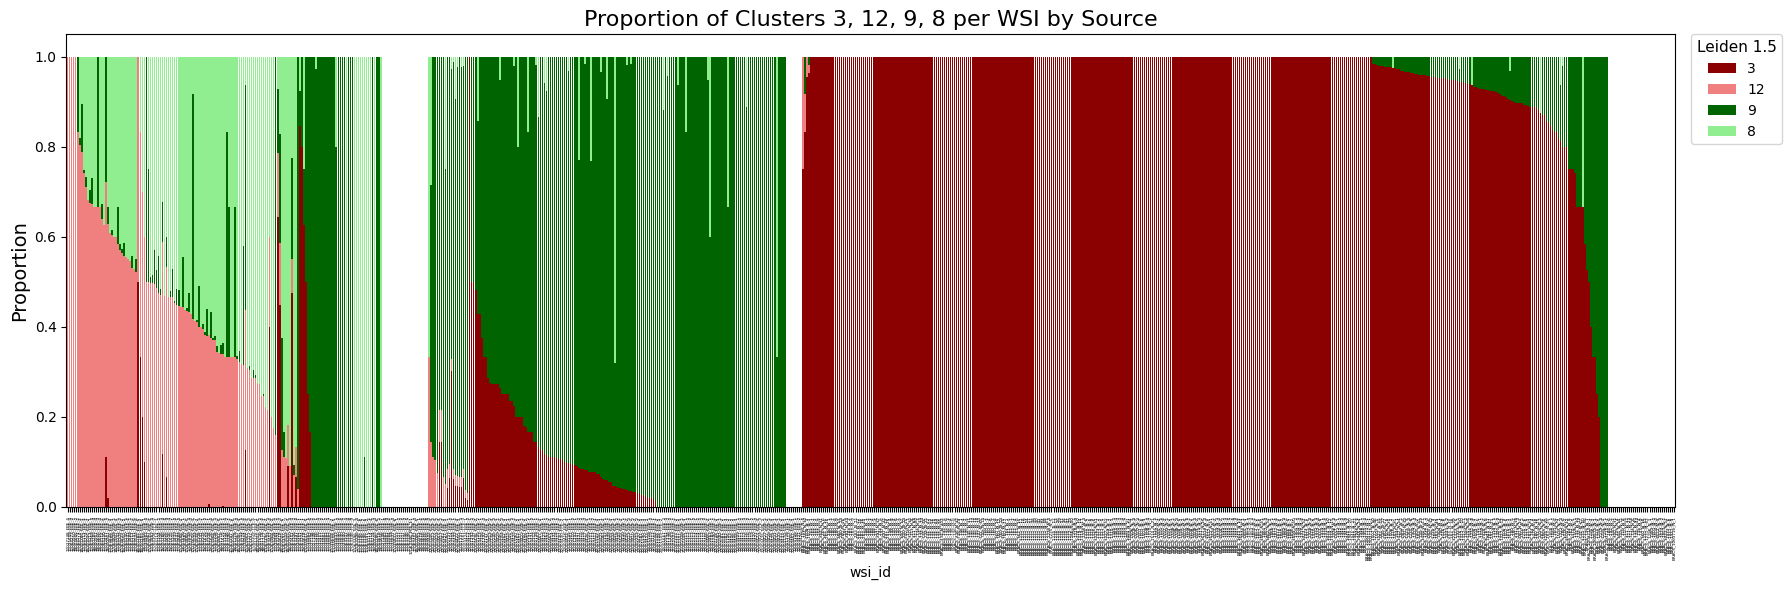

In [17]:
# Relative abundance of Clusters 3, 8, 9, 12
subset = adata_normal.obs.copy()
clusters = ['3', '12', '9', '8']
wsi_source = subset[['wsi_id', 'source']].drop_duplicates().set_index('wsi_id')
counts = subset.groupby(['wsi_id', 'leiden_1.5']).size().unstack(fill_value=0)
counts = counts[clusters] 
proportions = counts.div(counts.sum(axis=1), axis=0)
proportions = proportions.merge(wsi_source, left_index=True, right_index=True)
source_order = ['N_RM', 'N_RRM', 'N']
proportions['source'] = pd.Categorical(proportions['source'], categories=source_order, ordered=True)
proportions = proportions.sort_values(by=['source', '12', '3'], ascending=[True, False, False])


colors = {
    '3': '#8B0000',    # dark red
    '12': '#F08080',   # light red
    '9': '#006400',    # dark green
    '8': '#90EE90'     # light green
}
color_map = [colors[c] for c in clusters]
plot_data = proportions[clusters]


fig, ax = plt.subplots(figsize=(18, 6))
plot_data.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=color_map,
    width=0.8
)
ax.set_ylabel("Proportion", fontsize=14)
ax.set_title("Proportion of Clusters 3, 12, 9, 8 per WSI by Source", fontsize=16)
ax.set_xticklabels(plot_data.index, rotation=90, fontsize=8)
for tick, wsi_id in enumerate(plot_data.index):
    source_label = proportions.loc[wsi_id, 'source']
    ax.annotate(source_label, (tick, -0.05), xycoords='data',
                ha='center', va='top', fontsize=8, rotation=90)
ax.legend(
    title="Leiden 1.5", 
    fontsize=10, 
    title_fontsize=11,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    borderaxespad=0.
)
ax.set_xticklabels(plot_data.index, rotation=90, fontsize=3)


plt.tight_layout()
save_pt = f"{save_prefix}/leiden_1.5_clusters_3_8_9_12_stacked_barplot_relative.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

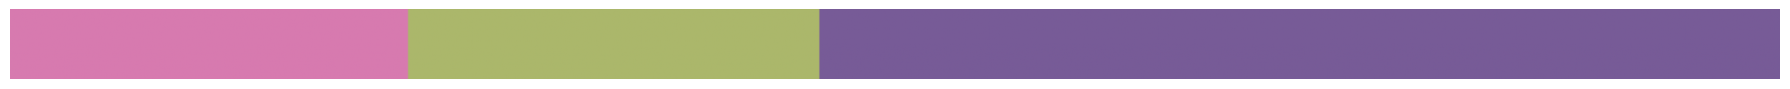

In [18]:
# NBT_source_annotation
source_data = proportions[['source']].copy()
source_colors = {
    'N_RM': '#D77AAF',   # 蓝
    'N_RRM': '#ABB76B',  # 橙
    'N': '#775B97'       # 绿
}
rgb_array = np.array([to_rgb(source_colors[s]) for s in source_data['source']])
rgb_image = rgb_array.reshape(1, -1, 3)

fig, ax = plt.subplots(figsize=(18, 1))
ax.imshow(rgb_image, aspect='auto')
ax.axis('off')

plt.tight_layout()
save_pt = f"{save_prefix}/leiden_1.5_clusters_3_8_9_12_NBT_source_annotation.pdf"
plt.savefig(save_pt, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [4]:
# ------------------------------------------------------------------------------------ #
# WSI mapping
gBRCAm_cluster3 = ['22003414_FPE_1', '21001292_FPE_2', '21001337_FPE_2', '22003436_FPE_2']
healthy_cluster3 = ['17063451_FPE_1', '17063104_FPE_1']
WSI_folder = "/cephfs/volumes/hpc_data_prj/cb_normalbreast/5bd8c988-b2ab-4eb6-b25f-6e47c2c4b969/prj_BreastAgeNet/WSIs"
FEATUREs = '/cephfs/volumes/hpc_data_prj/cb_normalbreast/5bd8c988-b2ab-4eb6-b25f-6e47c2c4b969/prj_BreastAgeNet/FEATUREs'

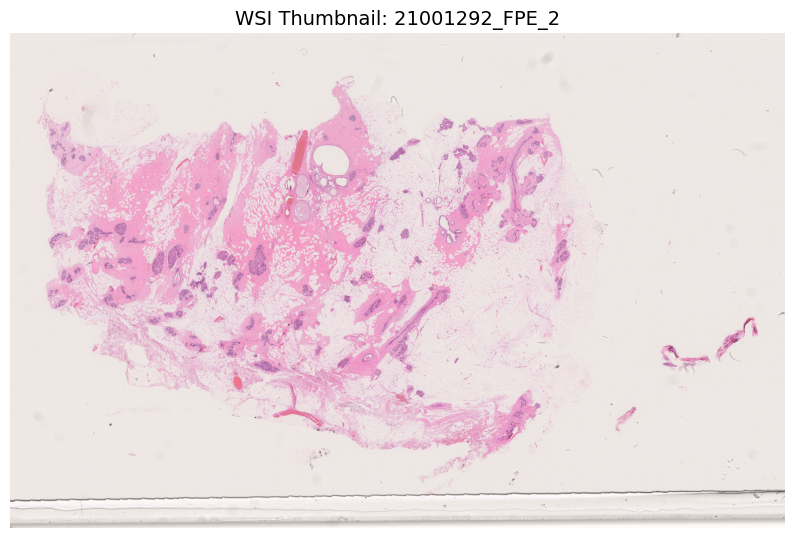

In [61]:
# WSI
sample_id = '21001292_FPE_2'
wsi_pt = glob.glob(f"{WSI_folder}/*/{sample_id}*")[0]
wsi = openslide.OpenSlide(wsi_pt)
thumbnail = wsi.get_thumbnail((wsi.dimensions[0] // 32, wsi.dimensions[1] // 32))
plt.figure(figsize=(10, 10))
plt.imshow(thumbnail)
plt.axis('off')
plt.title(f"WSI Thumbnail: {sample_id}", fontsize=14)
plt.show()

In [62]:
# predicted phenotype labels
phenotype_df = adata_normal.obs.loc[adata_normal.obs['wsi_id'] == sample_id, :]
print(f"There are {len(phenotype_df)} patches labeled by phenotypes" )
phenotype_df

There are 99 patches labeled by phenotypes


,patient_id,age,patch_id,cohort,wsi_id,source,leiden_0.5,umap1,umap2,leiden_0.5_top_samples,leiden_1.0,leiden_1.5,leiden_2.0,risk
41022,21001292,50.0,21001292_FPE_2_29847_44897_9171_8592_60_83_578,KHP,21001292_FPE_2,N_RRM,5,2.131517,-2.896495,False,6,10,5,1
41026,21001292,50.0,21001292_FPE_2_29847_44897_9171_8592_60_86_578,KHP,21001292_FPE_2,N_RRM,5,0.427689,-1.388364,False,5,17,4,1
41029,21001292,50.0,21001292_FPE_2_29847_44897_9171_8592_58_84_578,KHP,21001292_FPE_2,N_RRM,3,9.175284,3.352081,False,2,0,0,1
41036,21001292,50.0,21001292_FPE_2_21164_40845_6277_5698_43_74_578,KHP,21001292_FPE_2,N_RRM,5,1.717499,1.567922,False,1,4,7,1
41040,21001292,50.0,21001292_FPE_2_81944_61105_7434_10907_145_116_578,KHP,21001292_FPE_2,N_RRM,5,2.979788,0.679189,False,1,5,20,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41866,21001292,50.0,21001292_FPE_2_51265_69788_9171_5698_91_129_578,KHP,21001292_FPE_2,N_RRM,1,3.374294,6.336848,False,12,19,17,1
41883,21001292,50.0,21001292_FPE_2_21164_40845_6277_5698_42_74_578,KHP,21001292_FPE_2,N_RRM,5,0.625643,-1.014652,False,5,2,4,1
41898,21001292,50.0,21001292_FPE_2_21164_40845_6277_5698_41_76_578,KHP,21001292_FPE_2,N_RRM,3,4.842902,2.149324,False,6,5,20,1
41932,21001292,50.0,21001292_FPE_2_13639_40845_8592_6855_32_75_578,KHP,21001292_FPE_2,N_RRM,5,1.666165,-1.898380,False,6,10,5,1


In [63]:
# preidcted UNI-aug features
sample_features_pt = glob.glob(f"{FEATUREs}/*/{sample_id}/{sample_id}*UNI_aug*")[0]
with h5py.File(sample_features_pt, "r") as file:
    bag = np.array(file["embeddings"])
    bag = np.squeeze(bag)
    img_id = np.array(file["patch_id"])
img_id = [i.decode("utf-8") for i in img_id]

UNIaug_df = pd.DataFrame(bag)
UNIaug_df.index = img_id
print(f"There are {len(UNIaug_df)} patches extracted with UNI-aug features")
UNIaug_df

There are 514 patches extracted with UNI-aug features


,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
21001292_FPE_2_10166_23479_5698_5119_20_43_578,-1.361678,-0.080902,-0.062168,1.215435,0.198460,-1.286501,-0.096639,-0.880943,-1.550586,0.279128,...,-0.362110,1.256051,-0.156023,0.939092,-0.684158,-0.762763,-0.840684,-0.649023,-2.043485,-1.077798
21001292_FPE_2_10166_23479_5698_5119_21_43_578,-1.401576,-0.499003,1.950330,-2.422946,0.485222,-1.063688,1.857641,-2.146559,0.403819,0.766467,...,-0.343223,-0.547597,1.225184,1.136689,0.125028,-0.678965,-0.204078,1.020753,1.664148,0.467500
21001292_FPE_2_10166_23479_5698_5119_20_44_578,-0.501381,0.947496,-0.645680,-0.147516,0.420756,-0.947796,-0.902943,-1.174995,0.164890,-0.752598,...,1.840208,-0.236021,0.160624,0.471417,-0.709858,-0.230652,-0.946730,0.412928,-1.604180,-1.130894
21001292_FPE_2_10166_23479_5698_5119_21_44_578,-0.960087,-0.242585,0.855541,-2.364718,0.212932,-0.925619,0.822901,-1.263387,0.000724,0.558875,...,0.300100,0.039308,1.243894,1.627890,0.476307,-0.619472,-0.938402,0.859589,0.272816,-0.158295
21001292_FPE_2_10166_23479_5698_5119_22_44_578,-0.980037,0.343329,0.142296,-0.054349,-0.320905,0.175844,1.330463,-1.140514,-1.529797,-0.613225,...,1.121864,2.199182,-1.896930,0.641013,-1.342758,-0.185649,-0.654612,0.328406,0.192322,2.272582
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21001292_FPE_2_65157_72104_6277_5698_115_133_578,-1.752372,-0.786466,0.356655,-0.397870,-0.245249,0.308843,2.825330,-3.243735,-0.575592,0.433397,...,0.381690,-0.184423,1.046460,0.943991,-0.749831,-0.374710,-0.058351,0.382265,3.490417,0.853254
21001292_FPE_2_65157_72104_6277_5698_117_133_578,0.237259,-1.515385,-0.245487,-1.478041,0.604309,0.144077,0.850567,-1.925372,-0.253628,0.865416,...,1.096561,0.134959,-1.024334,0.447542,0.219421,-0.120527,-0.090070,0.615424,0.296130,0.466188
21001292_FPE_2_65157_72104_6277_5698_118_133_578,-0.719434,0.414016,-1.955952,0.539880,0.446741,0.197514,-0.003870,-1.343983,0.116528,0.228212,...,-0.033392,-0.453233,0.445447,-0.413060,0.687984,-0.030834,-0.127028,0.940512,0.190856,-0.253349
21001292_FPE_2_65157_72104_6277_5698_119_133_578,-1.421434,1.346824,-0.688923,-1.698716,0.426457,-0.041477,-0.705870,-2.787466,-1.705720,0.215372,...,1.140835,-2.237803,1.103521,0.934835,-0.444370,-0.332368,0.065686,-0.785697,2.070991,-1.022845


In [64]:
# all available patches from the WSI 
patch_pt = glob.glob(f"{FEATUREs}/*/{sample_id}/{sample_id}*patch*")[0]
patch_df = pd.read_csv(patch_pt)
patch_df.index = patch_df['patch_id']
patch_df['source'] = 'N_RRM'  
print(f"There are {len(patch_df)} patches across the slide")
patch_df

There are 514 patches across the slide


,roi_id,patch_id,cls,TC_epi,TC_str,TC_adi,cohort,wsi_id,source
patch_id,,,,,,,,,
21001292_FPE_2_10166_23479_5698_5119_20_43_578,21001292_FPE_2_10166_23479_5698_5119,21001292_FPE_2_10166_23479_5698_5119_20_43_578,epithelium,0.999679,0.000320,7.567484e-07,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_10166_23479_5698_5119_21_43_578,21001292_FPE_2_10166_23479_5698_5119,21001292_FPE_2_10166_23479_5698_5119_21_43_578,epithelium,0.745101,0.254743,1.551471e-04,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_10166_23479_5698_5119_20_44_578,21001292_FPE_2_10166_23479_5698_5119,21001292_FPE_2_10166_23479_5698_5119_20_44_578,epithelium,0.994197,0.005802,1.397057e-06,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_10166_23479_5698_5119_21_44_578,21001292_FPE_2_10166_23479_5698_5119,21001292_FPE_2_10166_23479_5698_5119_21_44_578,epithelium,0.540805,0.457250,1.945012e-03,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_10166_23479_5698_5119_22_44_578,21001292_FPE_2_10166_23479_5698_5119,21001292_FPE_2_10166_23479_5698_5119_22_44_578,epithelium,0.881003,0.118963,3.447704e-05,21001292_FPE_2,21001292_FPE_2,N_RRM
...,...,...,...,...,...,...,...,...,...
21001292_FPE_2_65157_72104_6277_5698_115_133_578,21001292_FPE_2_65157_72104_6277_5698,21001292_FPE_2_65157_72104_6277_5698_115_133_578,stroma,0.189194,0.809886,9.205396e-04,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_65157_72104_6277_5698_117_133_578,21001292_FPE_2_65157_72104_6277_5698,21001292_FPE_2_65157_72104_6277_5698_117_133_578,stroma,0.163908,0.835112,9.799470e-04,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_65157_72104_6277_5698_118_133_578,21001292_FPE_2_65157_72104_6277_5698,21001292_FPE_2_65157_72104_6277_5698_118_133_578,stroma,0.005790,0.992276,1.934538e-03,21001292_FPE_2,21001292_FPE_2,N_RRM


In [65]:
# merge to get new_df 
new_df = UNIaug_df.join(patch_df[['cohort', 'wsi_id', 'source']])

original_columns = UNIaug_df.columns[:1024]
new_columns = ['embedding_' + str(col) for col in original_columns]
rename_dict = dict(zip(original_columns, new_columns))
new_df = new_df.rename(columns=rename_dict)
new_df

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_1017,embedding_1018,embedding_1019,embedding_1020,embedding_1021,embedding_1022,embedding_1023,cohort,wsi_id,source
21001292_FPE_2_10166_23479_5698_5119_20_43_578,-1.361678,-0.080902,-0.062168,1.215435,0.198460,-1.286501,-0.096639,-0.880943,-1.550586,0.279128,...,0.939092,-0.684158,-0.762763,-0.840684,-0.649023,-2.043485,-1.077798,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_10166_23479_5698_5119_21_43_578,-1.401576,-0.499003,1.950330,-2.422946,0.485222,-1.063688,1.857641,-2.146559,0.403819,0.766467,...,1.136689,0.125028,-0.678965,-0.204078,1.020753,1.664148,0.467500,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_10166_23479_5698_5119_20_44_578,-0.501381,0.947496,-0.645680,-0.147516,0.420756,-0.947796,-0.902943,-1.174995,0.164890,-0.752598,...,0.471417,-0.709858,-0.230652,-0.946730,0.412928,-1.604180,-1.130894,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_10166_23479_5698_5119_21_44_578,-0.960087,-0.242585,0.855541,-2.364718,0.212932,-0.925619,0.822901,-1.263387,0.000724,0.558875,...,1.627890,0.476307,-0.619472,-0.938402,0.859589,0.272816,-0.158295,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_10166_23479_5698_5119_22_44_578,-0.980037,0.343329,0.142296,-0.054349,-0.320905,0.175844,1.330463,-1.140514,-1.529797,-0.613225,...,0.641013,-1.342758,-0.185649,-0.654612,0.328406,0.192322,2.272582,21001292_FPE_2,21001292_FPE_2,N_RRM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21001292_FPE_2_65157_72104_6277_5698_115_133_578,-1.752372,-0.786466,0.356655,-0.397870,-0.245249,0.308843,2.825330,-3.243735,-0.575592,0.433397,...,0.943991,-0.749831,-0.374710,-0.058351,0.382265,3.490417,0.853254,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_65157_72104_6277_5698_117_133_578,0.237259,-1.515385,-0.245487,-1.478041,0.604309,0.144077,0.850567,-1.925372,-0.253628,0.865416,...,0.447542,0.219421,-0.120527,-0.090070,0.615424,0.296130,0.466188,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_65157_72104_6277_5698_118_133_578,-0.719434,0.414016,-1.955952,0.539880,0.446741,0.197514,-0.003870,-1.343983,0.116528,0.228212,...,-0.413060,0.687984,-0.030834,-0.127028,0.940512,0.190856,-0.253349,21001292_FPE_2,21001292_FPE_2,N_RRM
21001292_FPE_2_65157_72104_6277_5698_119_133_578,-1.421434,1.346824,-0.688923,-1.698716,0.426457,-0.041477,-0.705870,-2.787466,-1.705720,0.215372,...,0.934835,-0.444370,-0.332368,0.065686,-0.785697,2.070991,-1.022845,21001292_FPE_2,21001292_FPE_2,N_RRM


In [66]:
# adata_ref: leiden 1.5 clusters as reference
n_neighbors = 15
resolution = 1.5
groupby = f"leiden_{resolution}"
adata_ref = adata_normal.copy()
sc.tl.pca(adata_ref, svd_solver='arpack')
sc.pp.neighbors(adata_ref, n_neighbors=n_neighbors, n_pcs=30, method='umap', metric='euclidean')
adata_ref.obs

,patient_id,age,patch_id,cohort,wsi_id,source,leiden_0.5,umap1,umap2,leiden_0.5_top_samples,leiden_1.0,leiden_1.5,leiden_2.0,risk
0,1003675,NaN,BRACS_1003675_N_1_1792_768,BRCAS,BRACS_1003675_N_1,N,1,3.759436,8.816525,False,0,1,1,2
1,1003675,NaN,BRACS_1003675_N_1_256_1024,BRCAS,BRACS_1003675_N_1,N,5,0.320499,4.078640,False,11,21,31,2
2,1003675,NaN,BRACS_1003675_N_1_1280_768,BRCAS,BRACS_1003675_N_1,N,1,4.204348,8.063508,False,0,1,1,2
3,1003675,NaN,BRACS_1003675_N_1_768_1024,BRCAS,BRACS_1003675_N_1,N,4,0.990095,4.295871,False,11,17,25,2
4,1003675,NaN,BRACS_1003675_N_1_256_1280,BRCAS,BRACS_1003675_N_1,N,5,0.473569,4.100793,False,11,21,31,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97271,773,NaN,BRACS_773_N_33_768_0,BRCAS,BRACS_773_N_33,N,1,3.437264,9.901889,False,0,14,28,2
97272,773,NaN,BRACS_773_N_33_768_256,BRCAS,BRACS_773_N_33,N,3,5.882754,1.325934,False,2,5,18,2
97273,773,NaN,BRACS_773_N_33_1280_512,BRCAS,BRACS_773_N_33,N,5,2.701497,2.551752,False,4,4,24,2
97274,773,NaN,BRACS_773_N_33_2048_512,BRCAS,BRACS_773_N_33,N,1,3.388751,4.773305,False,1,4,24,2


In [67]:
# adata_new
new_df['patch_id'] = new_df.index
adata_new = get_adata(new_df, annotations=['patch_id', 'cohort', 'wsi_id', 'source'])
sc.tl.pca(adata_new, svd_solver='arpack')
sc.pp.neighbors(adata_new, n_neighbors=n_neighbors, n_pcs=30, method='umap', metric='euclidean')
adata_new

AnnData object with n_obs × n_vars = 514 × 512
    obs: 'patch_id', 'cohort', 'wsi_id', 'source'
    uns: 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [68]:
# infer phenotypes for adata_new
adata_new.var_names = adata_ref.var_names  
sc.tl.ingest(adata_new, adata_ref, obs='leiden_1.5')

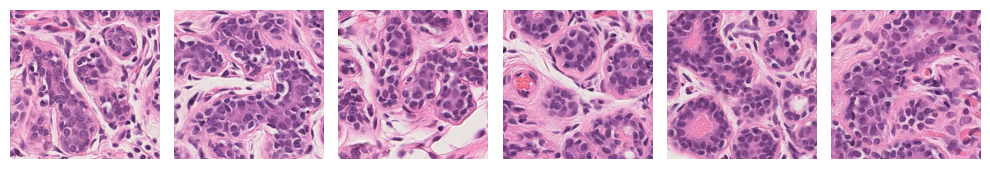

In [87]:
# visualise c3 HE images
cluster_label = '3'
patch_ids = list(adata_new.obs.loc[adata_new.obs['leiden_1.5'] == cluster_label, :]['patch_id'])
len(patch_ids)

img_list = []
for idx in patch_ids:
    try:
        patch = extract_patches(idx)  
        img_list.append(np.array(patch))
    except Exception as e:
        print(f"Warning: Skipping patch {idx} due to error: {e}")

img_list1 = random.sample(img_list, 6)
num_images = len(img_list1)
fig, axes = plt.subplots(1, 6, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(img_list1[i])
        ax.axis('off')
    else:
        ax.axis('off')
        
plt.tight_layout()
save_pt = f'{save_prefix}/{sample_id}_leiden1.5_c3_HEpatches.png'
plt.savefig(save_pt, bbox_inches='tight', dpi=300)
plt.show()

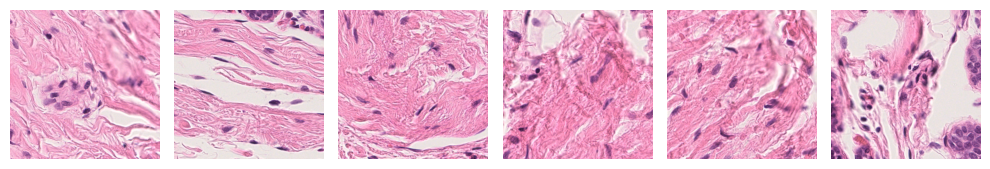

In [83]:
# visualise c9 HE images
cluster_label = '9'
patch_ids = list(adata_new.obs.loc[adata_new.obs['leiden_1.5'] == cluster_label, :]['patch_id'])
len(patch_ids)

img_list = []
for idx in patch_ids:
    try:
        patch = extract_patches(idx)  
        img_list.append(np.array(patch))
    except Exception as e:
        print(f"Warning: Skipping patch {idx} due to error: {e}")

img_list2 = random.sample(img_list, 6)
num_images = len(img_list2)
fig, axes = plt.subplots(1, 6, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(img_list2[i])
        ax.axis('off')
    else:
        ax.axis('off')
        
plt.tight_layout()
save_pt = f'{save_prefix}/{sample_id}_leiden1.5_c9_HEpatches.png'
plt.savefig(save_pt, bbox_inches='tight', dpi=300)
plt.show()

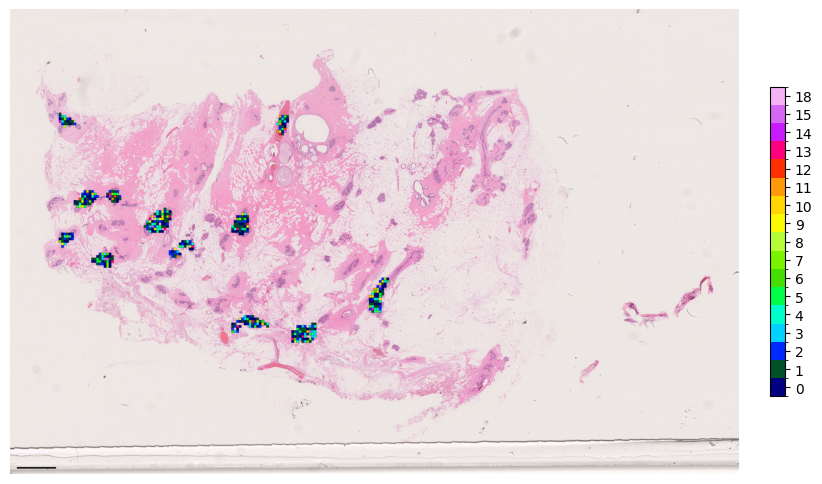

In [71]:
# trace all clusters back to WSI
new_df = adata_new.obs.copy()
# overlay clusters on the WSI
new_df["patch_size"] = [int(i.split("_")[-1]) for i in new_df["patch_id"]]
new_df["x_orig"] = [int(i.split("_")[-3]) * int(np.unique(new_df["patch_size"])) for i in new_df["patch_id"]]
new_df["y_orig"] = [int(i.split("_")[-2]) * int(np.unique(new_df["patch_size"])) for i in new_df["patch_id"]]

wsi_pt = glob.glob(f"{WSI_folder}/*/{sample_id}*")[0]
new_df['leiden_1.5'] = new_df['leiden_1.5'].astype(str)
unique_clusters = sorted(new_df['leiden_1.5'].unique(), key=lambda x: int(x))
cmap = plt.get_cmap('gist_ncar')  # 或 'tab20', 'nipy_spectral' 等
num_clusters = len(unique_clusters)
colors = [cmap(i / num_clusters) for i in range(num_clusters)]
colors_hex = [mcolors.rgb2hex(c[:3]) for c in colors]
cluster_colors = dict(zip(unique_clusters, colors_hex))

save_pt = f'{save_prefix}/{sample_id}_leiden1.5_WSImapping_all.png'
WSI_df, wsi_img = draw_wsi_with_clusters(new_df, wsi_pt, 'leiden_1.5', cluster_colors, level=5, save_pt=save_pt)

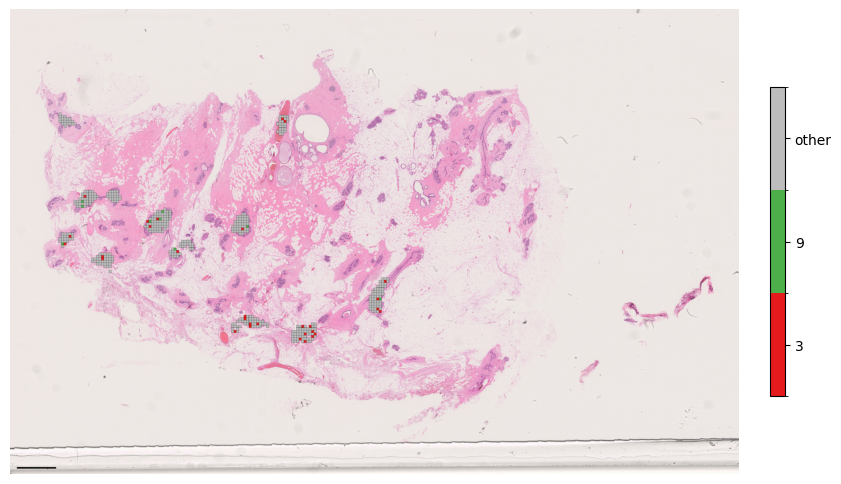

In [72]:
# trace c3 & c9 back to WSI
def map_label(x):
    if x == '3':
        return '3'
    elif x == '9':
        return '9'
    else:
        return 'other'

new_df['leiden_1.5_binary'] = new_df['leiden_1.5'].apply(map_label)
cluster_colors = {'3': '#e41a1c', '9': '#4daf4a', 'other': '#bdbdbd'}

save_pt = f'{save_prefix}/{sample_id}_leiden1.5_WSImapping_c3c9.png'
WSI_df, wsi_img = draw_wsi_with_clusters(new_df, wsi_pt, 'leiden_1.5_binary', cluster_colors, level=5, save_pt=save_pt)

In [100]:
# data-driven annotations for QuPath visualisation
json_pt = f'{save_prefix}/{sample_id}_leiden1.5_WSImapping_JSON_all.json'
get_JSON(WSI_df, 'leiden_1.5', json_pt, require_bounds=False, wsi=None)

Saved to /scratch/prj/cb_microbiome/recovered/Siyuan/prj_NBTPhenotyping/RESULTS/WSI_mapping05/21001292_FPE_2_leiden1.5_WSImapping_JSON_all.json


In [ ]:
gBRCAm_cluster3 = ['22003414_FPE_1', '21001292_FPE_2', '21001337_FPE_2', '22003436_FPE_2']
WSI_folder = "/cephfs/volumes/hpc_data_prj/cb_normalbreast/5bd8c988-b2ab-4eb6-b25f-6e47c2c4b969/prj_BreastAgeNet/WSIs"
FEATUREs = '/cephfs/volumes/hpc_data_prj/cb_normalbreast/5bd8c988-b2ab-4eb6-b25f-6e47c2c4b969/prj_BreastAgeNet/FEATUREs'
sample_id = '21001292_FPE_2'
# ------------------------------------------------------------------------------------ #
# WSI
wsi_pt = glob.glob(f"{WSI_folder}/*/{sample_id}*")[0]
wsi = openslide.OpenSlide(wsi_pt)
thumbnail = wsi.get_thumbnail((wsi.dimensions[0] // 32, wsi.dimensions[1] // 32))
plt.figure(figsize=(8, 8))
plt.imshow(thumbnail)
plt.axis('off')
plt.title(f"WSI Thumbnail: {sample_id}", fontsize=14)
plt.show()
# ------------------------------------------------------------------------------------ #
# predicted phenotype labels
phenotype_df = adata_normal.obs.loc[adata_normal.obs['wsi_id'] == sample_id, :]
print(f"There are {len(phenotype_df)} patches labeled by phenotypes" )
# ------------------------------------------------------------------------------------ #
# preidcted UNI-aug features
sample_features_pt = glob.glob(f"{FEATUREs}/*/{sample_id}/{sample_id}*UNI_aug*")[0]
with h5py.File(sample_features_pt, "r") as file:
    bag = np.array(file["embeddings"])
    bag = np.squeeze(bag)
    img_id = np.array(file["patch_id"])
img_id = [i.decode("utf-8") for i in img_id]

UNIaug_df = pd.DataFrame(bag)
UNIaug_df.index = img_id
print(f"There are {len(UNIaug_df)} patches extracted with UNI-aug features")
# ------------------------------------------------------------------------------------ #
# all available patches from the WSI 
patch_pt = glob.glob(f"{FEATUREs}/*/{sample_id}/{sample_id}*patch*")[0]
patch_df = pd.read_csv(patch_pt)
patch_df.index = patch_df['patch_id']
patch_df['source'] = 'N_RRM'  
print(f"There are {len(patch_df)} patches across the slide")
# ------------------------------------------------------------------------------------ #
# merge to get new_df 
new_df = UNIaug_df.join(patch_df[['cohort', 'wsi_id', 'source']])

original_columns = UNIaug_df.columns[:1024]
new_columns = ['embedding_' + str(col) for col in original_columns]
rename_dict = dict(zip(original_columns, new_columns))
new_df = new_df.rename(columns=rename_dict)
# ------------------------------------------------------------------------------------ #
# adata_ref: leiden 1.5 clusters as reference
n_neighbors = 15
resolution = 1.5
groupby = f"leiden_{resolution}"
adata_ref = adata_normal.copy()
sc.tl.pca(adata_ref, svd_solver='arpack')
sc.pp.neighbors(adata_ref, n_neighbors=n_neighbors, n_pcs=30, method='umap', metric='euclidean')
# ------------------------------------------------------------------------------------ #
# adata_new
new_df['patch_id'] = new_df.index
adata_new = get_adata(new_df, annotations=['patch_id', 'cohort', 'wsi_id', 'source'])
sc.tl.pca(adata_new, svd_solver='arpack')
sc.pp.neighbors(adata_new, n_neighbors=n_neighbors, n_pcs=30, method='umap', metric='euclidean')
# ------------------------------------------------------------------------------------ #
# infer phenotypes for adata_new
adata_new.var_names = adata_ref.var_names  
sc.tl.ingest(adata_new, adata_ref, obs='leiden_1.5')
# ------------------------------------------------------------------------------------ #
# visualise c3 HE images
cluster_label = '3'
patch_ids = list(adata_new.obs.loc[adata_new.obs['leiden_1.5'] == cluster_label, :]['patch_id'])
len(patch_ids)

img_list = []
for idx in patch_ids:
    try:
        patch = extract_patches(idx)  
        img_list.append(np.array(patch))
    except Exception as e:
        print(f"Warning: Skipping patch {idx} due to error: {e}")

img_list1 = random.sample(img_list, 6)
num_images = len(img_list1)
fig, axes = plt.subplots(1, 6, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(img_list1[i])
        ax.axis('off')
    else:
        ax.axis('off')
        
plt.tight_layout()
save_pt = f'{save_prefix}/{sample_id}_leiden1.5_c3_HEpatches.png'
plt.savefig(save_pt, bbox_inches='tight', dpi=300)
plt.title("high-risk epithelium phenotypes: c3 cluster")
plt.show()
# ------------------------------------------------------------------------------------ #
# visualise c9 HE images
cluster_label = '9'
patch_ids = list(adata_new.obs.loc[adata_new.obs['leiden_1.5'] == cluster_label, :]['patch_id'])
len(patch_ids)

img_list = []
for idx in patch_ids:
    try:
        patch = extract_patches(idx)  
        img_list.append(np.array(patch))
    except Exception as e:
        print(f"Warning: Skipping patch {idx} due to error: {e}")

img_list2 = random.sample(img_list, 6)
num_images = len(img_list2)
fig, axes = plt.subplots(1, 6, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    if i < num_images:
        ax.imshow(img_list2[i])
        ax.axis('off')
    else:
        ax.axis('off')
        
plt.tight_layout()
save_pt = f'{save_prefix}/{sample_id}_leiden1.5_c9_HEpatches.png'
plt.savefig(save_pt, bbox_inches='tight', dpi=300)
plt.title("high-risk peri-lobular stroma phenotypes: c9 cluster")
plt.show()
# ------------------------------------------------------------------------------------ #
# trace all clusters back to WSI
new_df = adata_new.obs.copy()
# overlay clusters on the WSI
new_df["patch_size"] = [int(i.split("_")[-1]) for i in new_df["patch_id"]]
new_df["x_orig"] = [int(i.split("_")[-3]) * int(np.unique(new_df["patch_size"])) for i in new_df["patch_id"]]
new_df["y_orig"] = [int(i.split("_")[-2]) * int(np.unique(new_df["patch_size"])) for i in new_df["patch_id"]]

wsi_pt = glob.glob(f"{WSI_folder}/*/{sample_id}*")[0]
new_df['leiden_1.5'] = new_df['leiden_1.5'].astype(str)
unique_clusters = sorted(new_df['leiden_1.5'].unique(), key=lambda x: int(x))
cmap = plt.get_cmap('gist_ncar')  # 或 'tab20', 'nipy_spectral' 等
num_clusters = len(unique_clusters)
colors = [cmap(i / num_clusters) for i in range(num_clusters)]
colors_hex = [mcolors.rgb2hex(c[:3]) for c in colors]
cluster_colors = dict(zip(unique_clusters, colors_hex))

save_pt = f'{save_prefix}/{sample_id}_leiden1.5_WSImapping_all.png'
WSI_df, wsi_img = draw_wsi_with_clusters(new_df, wsi_pt, 'leiden_1.5', cluster_colors, level=5, save_pt=save_pt)
# ------------------------------------------------------------------------------------ #
# trace c3 & c9 back to WSI
def map_label(x):
    if x == '3':
        return '3'
    elif x == '9':
        return '9'
    else:
        return 'other'

new_df['leiden_1.5_binary'] = new_df['leiden_1.5'].apply(map_label)
cluster_colors = {'3': '#e41a1c', '9': '#4daf4a', 'other': '#bdbdbd'}

save_pt = f'{save_prefix}/{sample_id}_leiden1.5_WSImapping_c3c9.png'
WSI_df, wsi_img = draw_wsi_with_clusters(new_df, wsi_pt, 'leiden_1.5_binary', cluster_colors, level=5, save_pt=save_pt)
# ------------------------------------------------------------------------------------ #
# data-driven annotations for QuPath visualisation
json_pt = f'{save_prefix}/{sample_id}_leiden1.5_WSImapping_JSON_all.json'
get_JSON(WSI_df, 'leiden_1.5', json_pt, require_bounds=False, wsi=None)